# init

In [ ]:
# !pip install cloudscraper
# import cloudscraper
import urllib3
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import sleep
from time import time
import requests
from bs4 import Comment
header: str = "https://www.basketball-reference.com"

def soupify(url: str):

    http = urllib3.PoolManager()
    response = http.request('GET', url)
    soup = BeautifulSoup(response.data)

    return soup

# def soupify_with_cloudscraper(url):
#     scraper = cloudscraper.create_scraper()
#     response = scraper.get(url)
#     return BeautifulSoup(response.text, 'html.parser')

# scraping school stats

In [ ]:
# stats_page_url: str = "https://www.sports-reference.com/cbb/seasons/men/2026-school-stats.html"
stats_page_url: str = "https://www.sports-reference.com/cbb/seasons/men/2026-opponent-stats.html"

In [ ]:
s = soupify(stats_page_url)

In [ ]:
schools = list(t for t in s.find('table').find('tbody').find_all('tr') if t.find('sup'))

In [ ]:
cols = ["school_name", "g", "srs", "sos","pts","mp",
        "fg","fga","fg_pct","fg3","fg3a","fg3_pct",
        "ft","fta","ft_pct", "orb","trb","ast","stl",
        "blk","tov","pf"]
stats26: "pd.DataFrame" = pd.DataFrame(columns = cols)
for i in range(len(schools)):
    stats26.loc[len(stats26.index)] = {col:schools[i].find("td", {"data-stat":col}).contents[0] if col != "school_name" else schools[i].find("a").contents[0] for col in cols}

In [ ]:
cols = ["pts",
        "fg","fga","fg_pct","fg3","fg3a","fg3_pct",
        "ft","fta","ft_pct", "orb","trb","ast","stl",
        "blk","tov","pf"]
cols = list("opp_" + col for col in cols)
cols.insert(0, "school_name")
oppstats26: "pd.DataFrame" = pd.DataFrame(columns = cols)
for i in range(len(schools)):
    oppstats26.loc[len(oppstats26.index)] = {(col):schools[i].find("td", {"data-stat":col}).contents[0] if col != "school_name" else schools[i].find("a").contents[0] for col in cols}

In [ ]:
teamstats26 = pd.merge(stats26, oppstats26).copy()

In [ ]:
for col in teamstats26.columns[1:]:
    teamstats26[col] = pd.to_numeric(teamstats26[col])
teamstats26["drb"] = teamstats26["trb"] - teamstats26["orb"]
teamstats26["opp_drb"] = teamstats26["opp_trb"] - teamstats26["opp_orb"]

In [ ]:
teamstats26.to_csv("stats26.csv")

In [ ]:
teamstats26["poss"] = 0.5*(teamstats26["fga"] + 0.475*teamstats26["fta"] - teamstats26["orb"] + teamstats26["tov"]) + 0.5*(teamstats26["opp_fga"] + 0.475*teamstats26["opp_fta"] - teamstats26["opp_orb"] + teamstats26["opp_tov"])

In [ ]:
for col in list(col for col in teamstats26.columns[4:] if "pct" not in col and "mp" not in col)[:-1]:
    if "pts" in col:
        if "opp" in col:
            teamstats26["DRtg"] = 100*(teamstats26[col]/teamstats26["poss"])
        else:
            teamstats26["ORtg"] = 100*(teamstats26[col]/teamstats26["poss"])
    else:
        teamstats26[f"{col}_100poss"] = 100*(teamstats26[col]/teamstats26["poss"])
teamstats26["pace"] = 40*teamstats26["poss"]/(teamstats26["mp"])

In [ ]:
for col in list(col for col in teamstats26.columns[4:] if "pct" not in col and "mp" not in col)[:30]:
    teamstats26[f"{col}_g"] = (teamstats26[col]/teamstats26["g"])

In [ ]:
teamstats26["efg"] = (teamstats26["fg"] + .5*teamstats26["fg3"])/teamstats26["fga"]
teamstats26["ts"] = teamstats26["pts"]/(2*(teamstats26["fga"] + .475*teamstats26["fta"]))
teamstats26["net_rtg"] = teamstats26["ORtg"] - teamstats26["DRtg"]
teamstats26["ftr"] = teamstats26["fta"]/teamstats26["fga"]
teamstats26["ft_fga"] = teamstats26["ft"]/teamstats26["fga"]
teamstats26["tov_pct"] = 100*teamstats26["tov"]/(teamstats26["fga"] + .475*teamstats26["fta"] + teamstats26["tov"])
teamstats26["orb_pct"] = teamstats26["orb"]/(teamstats26["orb"] + teamstats26["opp_drb"])
teamstats26["pyth_W"] = teamstats26["g"]*(teamstats26["pts"]/(teamstats26["pts"] + teamstats26["opp_pts"]))
teamstats26["pyth_L"] = teamstats26["g"] - teamstats26["pyth_W"]
teamstats26["3par"] = teamstats26["fg3a"]/teamstats26["fga"]

teamstats26["opp_efg"] = (teamstats26["opp_fg"] + .5*teamstats26["opp_fg3"])/teamstats26["opp_fga"]
teamstats26["opp_ts"] = teamstats26["opp_pts"]/(2*(teamstats26["opp_fga"] + .475*teamstats26["opp_fta"]))
teamstats26["opp_ftr"] = teamstats26["opp_fta"]/teamstats26["opp_fga"]
teamstats26["opp_ft_fga"] = teamstats26["opp_ft"]/teamstats26["opp_fga"]
teamstats26["opp_tov_pct"] = 100*teamstats26["opp_tov"]/(teamstats26["opp_fga"] + .475*teamstats26["opp_fta"] + teamstats26["opp_tov"])
teamstats26["opp_orb_pct"] = teamstats26["opp_orb"]/(teamstats26["opp_orb"] + teamstats26["drb"])
teamstats26["opp_3par"] = teamstats26["opp_fg3a"]/teamstats26["opp_fga"]

In [ ]:
# teamstats26.loc[teamstats26["school_name"] == "Wright State",list(c for c in teamstats26.columns if "pct" in c)]
teamstats26.to_csv("teamstats26.csv")

In [ ]:
# teamstats26[["school_name", "pts", "opp_pts", "ORtg","DRtg"]]
# 0.5*(1996 + 0.475*753 - 383 + 383) + 0.5*(1963 + 0.475*658 - 325 + 407)
teamstats26.loc[teamstats26["school_name"] == "Wright State",["pace"]]

,pace
67,69.028938


# scraping bracket

In [ ]:
bracket_url: str = "https://www.sports-reference.com/cbb/postseason/men/2026-ncaa.html"

In [ ]:
s = soupify(bracket_url)

In [ ]:
s.find('div', {"id" : "midwest"}).find('p').find_all('a')

[<a href="/cbb/schools/maryland-baltimore-county/men/2026.html">UMBC</a>,
 <a href="/cbb/schools/howard/men/2026.html">Howard</a>,
 <a href="/cbb/schools/miami-oh/men/2026.html">Miami (OH)</a>,
 <a href="/cbb/schools/southern-methodist/men/2026.html">SMU</a>]

In [ ]:
first_four: "pd.DataFrame" = pd.DataFrame(columns = ["region","team","seed"])
ff_bool: bool = False
for region in ["east","midwest","south","west"]:
    field = s.find('div', {"id" : region})
    if field.find('p'):
        ff_bool = True
        ff_seeds = list(int(s.contents[0]) for s in field.find('p').find_all('strong')[1:])
        ff_teams = list(t.contents[0] for t in field.find('p').find_all('a'))
        ff_region_col = [region]*len(ff_teams)
        first_four = pd.concat([first_four, pd.DataFrame({"region":ff_region_col,
                                       "team":ff_teams,
                                       "seed":ff_seeds})])
        ff_matchups = {ff_seeds[2*i]:f"{ff_teams[2*i]}/{ff_teams[2*i + 1]}" for i in range(len(ff_teams)//2)}
        print(ff_matchups)

{16: 'UMBC/Howard', 11: 'Miami (OH)/SMU'}
{16: 'Prairie View A&M/Lehigh'}
{11: 'Texas/NC State'}


In [ ]:
matchups: "pd.DataFrame" = pd.DataFrame(columns = ["region","team","seed"])
first_four: "pd.DataFrame" = pd.DataFrame(columns = ["region","team","seed"])
ff_bool: bool = False
for region in ["east","midwest","south","west"]:
    field = s.find('div', {"id" : region})
    if field.find('p'):
        ff_bool = True
        seeds = list(int(s.contents[0]) for s in field.find('p').find_all('strong')[1:])
        teams = list(t.contents[0] for t in field.find('p').find_all('a'))
        region_col = [region]*len(teams)
        ff_matchups = {seeds[2*i]:f"{teams[2*i]}/{teams[2*i + 1]}" for i in range(len(teams)//2)}
        first_four = pd.concat([first_four, pd.DataFrame({"region":region_col,
                                       "team":teams,
                                       "seed":seeds})])
    field = field.find('div')
    seeds = list(f for f in field.find_all('span') if f.contents)
    seeds = list(int(f.contents[0]) for f in seeds if f.contents[0].isnumeric())
    teams = list(t.contents[0] for t in field.find_all('a'))
    if ff_bool:
        for seed in ff_matchups.keys():
            seeds.insert(seeds.index(6) + 1, seed) if seed == 11 else seeds.insert(seeds.index(1) + 1, seed)
            teams.insert(seeds.index(6) + 1, ff_matchups[seed]) if seed == 11 else teams.insert(seeds.index(1) + 1, ff_matchups[seed])
    region_col = [region]*len(teams)
    matchups = pd.concat([matchups, pd.DataFrame({"region":region_col,
                                       "team":teams,
                                       "seed":seeds})])
teamseeds = matchups.copy()
ff_teamseeds = first_four.copy()

In [ ]:
replacements = {"Connecticut":"UConn", "Brigham Young" : "BYU",
                "North Carolina":"UNC","Southern Methodist" : "SMU",
                "Texas Christian" : "TCU", "Virginia Commonwealth" : "VCU",
                "Maryland-Baltimore County" : "UMBC", "Long Island University" : "LIU",
                "Pennsylvania" : "Penn"}

In [ ]:
matchups = pd.DataFrame(columns = ["region", "team1", "team1_seed","team2", "team2_seed"])
teamVS = list(zip(teamseeds["team"].values[::2], teamseeds["team"].values[1::2]))
seedVS = list(zip(teamseeds["seed"].values[::2], teamseeds["seed"].values[1::2]))
regions = teamseeds["region"].values[::2]

for i in range(32):
    t1, t2 = teamVS[i]
    if t1 in replacements.keys():
        t1 = replacements[t1]
    if t2 in replacements.keys():
        t2 = replacements[t2]
    s1, s2 = (seedVS)[i]
    matchups.loc[len(matchups.index)] = [regions[i], t1, s1, t2, s2]

In [ ]:
ff_matchups = pd.DataFrame(columns = ["region", "team1", "team1_seed","team2", "team2_seed"])
teamVS = list(zip(ff_teamseeds["team"].values[::2], ff_teamseeds["team"].values[1::2]))
seedVS = list(zip(ff_teamseeds["seed"].values[::2], ff_teamseeds["seed"].values[1::2]))
regions = ff_teamseeds["region"].values[::2]

for i in range(4):
    t1, t2 = teamVS[i]
    if t1 in replacements.keys():
        t1 = replacements[t1]
    if t2 in replacements.keys():
        t2 = replacements[t2]
    s1, s2 = (seedVS)[i]
    ff_matchups.loc[len(ff_matchups.index)] = [regions[i], t1, s1, t2, s2]

In [ ]:
ff_matchups.to_csv("firstFour_matchups.csv")

In [ ]:
matchups.to_csv("matchups26.csv")

In [ ]:
for i in range(len(teamstats26)):
    if teamstats26.loc[i,"school_name"] in replacements.keys():
       teamstats26.loc[i,"school_name"] = replacements[teamstats26.loc[i,"school_name"]]

In [ ]:
teamstats26.to_csv("teamstats26.csv")

In [ ]:
list(t for t in list(teamstats26["school_name"].values) if t not in (list(teamseeds["team"].values) + (list(ff_teamseeds["team"].values))))

['Brigham Young',
 'Connecticut',
 'Long Island University',
 'Maryland-Baltimore County',
 'North Carolina',
 'Pennsylvania',
 'Southern Methodist',
 'Texas Christian',
 'Virginia Commonwealth']

# making matchups df

In [ ]:
matchups_nostats = matchups.copy()

In [ ]:
matchups_nostats = matchups_nostats.loc[~(matchups_nostats["team2"].str.contains("/")),]
temp = pd.concat([pd.merge(matchups_nostats[["region","team1","team1_seed"]], teamstats26.add_suffix("_team1"), left_on="team1", right_on = "school_name_team1").drop("school_name_team1", axis = 1),
         pd.merge(matchups_nostats[["team2","team2_seed"]], teamstats26.add_suffix("_team2"), left_on="team2", right_on = "school_name_team2").drop("school_name_team2", axis = 1)],
          axis = 1).copy()

In [ ]:
fftemp = pd.concat([pd.merge(ff_matchups[["region","team1","team1_seed"]], teamstats26.add_suffix("_team1"), left_on="team1", right_on = "school_name_team1").drop("school_name_team1", axis = 1),
         pd.merge(ff_matchups[["team2","team2_seed"]], teamstats26.add_suffix("_team2"), left_on="team2", right_on = "school_name_team2").drop("school_name_team2", axis = 1)],
          axis = 1).copy()

In [ ]:
fftemp[["region","team1","team1_seed","team2","team2_seed"]]

,region,team1,team1_seed,team2,team2_seed
0,midwest,UMBC,16,Howard,16
1,midwest,Miami (OH),11,SMU,11
2,south,Prairie View A&M,16,Lehigh,16
3,west,Texas,11,NC State,11


In [ ]:
temp.to_csv("database26.csv")
fftemp.to_csv("ff_database26.csv")

# after tourney

In [ ]:
bracket_url: str = "https://www.sports-reference.com/cbb/postseason/men/2026-ncaa.html"
s = soupify(bracket_url)

In [ ]:
list(d.get("id") for d in s.find('div', {"id" : "brackets"}).find_all("div") if d.get('id') and "team16" not in d.get('class') and "team4" not in d.get('class') )

# region div id = region
# within region, div class = team16

# list(sp.contents[0] for sp in s.find('div', {"id" : "brackets"}).find('div', {"class" : "round"}).find_all('span') if not sp.find('a'))
# list(sc.contents[0] for sc in s.find('div', {"id" : "brackets"}).find('div', {"class" : "round"}).find_all('a') if "schools" in sc["href"])
# list(g.find('a').contents[0] for g in s.find('div', {"id" : "brackets"}).find('div', {"class" : "round"}).find_all('div', {"class" : "winner"}))

['east', 'midwest', 'south', 'west', 'national']

In [ ]:
results = pd.DataFrame(columns = ["region", "round", "seed_team1", "seed_team2", "team1", "team2", "win_team1"])
seeds = list(sp.contents[0] for sp in s.find('div', {"id" : "brackets"}).find('div', {"class" : "round"}).find_all('span') if not sp.find('a'))
teams = list(sc.contents[0] for sc in s.find('div', {"id" : "brackets"}).find('div', {"class" : "round"}).find_all('a') if "schools" in sc["href"])
winners = list(g.find('a').contents[0] for g in s.find('div', {"id" : "brackets"}).find('div', {"class" : "round"}).find_all('div', {"class" : "winner"}))
for i in range(8):
    results.loc[len(results.index)] = ["east", len(teams)*4,
                                       seeds[2*i], seeds[2*i + 1],
                                       teams[2*i], teams[2*i + 1],
                                       1 if winners[i] ==  teams[2*i] else 0]

In [ ]:
results = pd.DataFrame(columns = ["year", "region", "round", "team1", "team2", "seed_team1", "seed_team2", "win_team1"])
url_keys = pd.DataFrame(columns = ["team", "key"])
# for season in range(2000, 2026):
for season in range(2021, 2022):
    bracket_url: str = f"https://www.sports-reference.com/cbb/postseason/men/{season}-ncaa.html"
    s = soupify(bracket_url)
    regions = list(d.get("id") for d in s.find('div', {"id" : "brackets"}).find_all("div") if d.get('id') and "team16" not in d.get('class') and "team4" not in d.get('class') )
    for region in regions:
    # for region in ['east', 'midwest', 'south', 'west', 'national']:
        for round in s.find('div', {"id" : "brackets"}).find('div', {"id" : region}).find_all('div', {"class" : "round"}):
            seeds = list(sp.contents[0] for sp in round.find_all('span') if not sp.find('a'))
            teams = list(sc.contents[0] for sc in round.find_all('a') if "schools" in sc["href"])
            urls = list(sc["href"].split('schools/')[1].split('/men')[0] for sc in round.find_all('a') if "schools" in sc["href"])
            urls = {teams[i] : urls[i] for i in range(len(teams))}
            winners = list(g.find('a').contents[0] for g in round.find_all('div', {"class" : "winner"}))
            if region == "west":
                print(teams)
            for i in range(len(winners)):
                results.loc[len(results.index)] = [season, region, len(teams)*4 if region != "national" else len(teams),
                                                  teams[2*i], teams[2*i + 1],
                                                  seeds[2*i], seeds[2*i + 1],
                                                  1 if winners[i] ==  teams[2*i] else 0]
            for team in teams:
                if team not in url_keys["team"].values:
                    url_keys.loc[len(url_keys.index)] = [team, urls[team]]
    sleep(5)

['Gonzaga', 'Norfolk State', 'Oklahoma', 'Missouri', 'Creighton', 'UC Santa Barbara', 'Virginia', 'Ohio', 'USC', 'Drake', 'Kansas', 'Eastern Washington', 'Oregon', 'VCU', 'Iowa', 'Grand Canyon']
['Gonzaga', 'Oklahoma', 'Creighton', 'Ohio', 'USC', 'Kansas', 'Oregon', 'Iowa']
['Gonzaga', 'Creighton', 'USC', 'Oregon']
['Gonzaga', 'USC']
['Gonzaga']


In [ ]:
results.to_csv("MMresults.csv", index=False)
url_keys.to_csv("url_keys.csv", index = False)

In [ ]:
results.loc[results["seed_team2"] == "15",]

,year,region,round,team1,team2,seed_team1,seed_team2,win_team1
7,2021,east,64,Alabama,Iona,2,15,1
22,2021,midwest,64,Houston,Cleveland State,2,15,1
37,2021,south,64,Ohio State,Oral Roberts,2,15,0
41,2021,south,32,Florida,Oral Roberts,7,15,0
43,2021,south,16,Arkansas,Oral Roberts,3,15,1


In [ ]:
prev_results = pd.read_csv("MMresults.csv")
prev_results.loc[prev_results["region"] == "national","round"] = [4,4,2]*25

In [ ]:
# pd.concat([prev_results, results]).to_csv("MMresults.csv", index = False)

In [ ]:
pd.concat([pd.read_csv("url_keys.csv"), url_keys]).groupby(["team", "key"]).head(1).to_csv("url_keys.csv", index = False)

In [ ]:
# results = pd.read_csv("MMresults.csv")
# results = pd.concat([prev_results, results]).copy()
# for col in {"year", "round", "seed_team1", "seed_team2", "win_team1"}:
#     results[col] = pd.to_numeric(results[col])
# results.loc[(results["round"] == 64) & (results["seed_team2"] >= 14) & (results["year"] == 2021),] #.groupby("year").count()
# results.loc[(results["team1"] == "Oregon") & (results["team2"] == "VCU"),"win_team1"] = 1
# results.loc[len(results.index)] = [2021, "west", 64, "Iowa", "Grand Canyon", 2, 15, 1]
# results.to_csv("MMresults.csv", index = False)

# analysis

In [ ]:
# 14-16 seeds were 20-280 entering 2026
# 0-12 in 2026
# results.loc[(results["round"] == 64) & (results["seed_team2"] >= 14),].groupby(["year","win_team1"]).count()["region"].reset_index().groupby("win_team1").sum()

# all round 1 upsets
# results.loc[(results["round"] == 64),].groupby("year")["win_team1"].mean()

diff: int = 6
temp = results.loc[((results['seed_team1'] >= results["seed_team2"] + diff) & (results["win_team1"] == 1)) |
             ((results['seed_team1'] + diff <= results["seed_team2"]) & (results["win_team1"] == 0)),].copy()
temp = temp.groupby("year").count()["region"].reset_index().rename(columns = {"region" : "count"})
temp.head()

,year,count
0,2000,4
1,2001,6
2,2002,9
3,2003,4
4,2004,5


i'm trying to build a python loop that iterates through a dataset of march madness results. the dataset is simply the matchups with teams and seeds and "win" if team1 won. my goal is to compare the rate of upsets in 2000-25 to 2026 and my loop defines upset by a different definition each time. the variable "diff" defines the threshold required from the difference in seeds to be considered as an upset. Using the shorter dataset, I run a bootstrap interval. Is this code correct for my objective?

I have a question about approaches to this problem because they are generating very different results:

approach 1: compare bootstrap interval of previous years' upset to a static value of the upset rate of 2026, where the length of the bootstrap interval is the length of the 2026 slate of games (63) -> not significant difference

approach 2: compare bootstrap interval of previous years' upset to a static value of the upset rate of 2026, where the length of the bootstrap interval is the length of the combined pool of previous years (63*24) -> significant difference

approach 3: compare mean of  bootstrap interval of previous years' upset rate to mean of bootstrap interval of 2026 upset rate, where the length of the prev years bootstrap interval is the length of the combined pool of previous years (63*24) and the 26 bootstrap interval is length 63 -> not significant difference

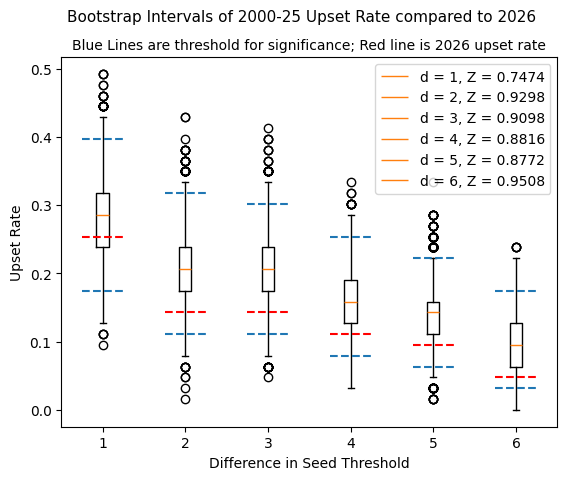

In [ ]:
for diff in range(1, 7):
    temp = results.loc[((results['seed_team1'] >= results["seed_team2"] + diff) & (results["win_team1"] == 1)) |
                ((results['seed_team1'] + diff <= results["seed_team2"]) & (results["win_team1"] == 0)),].copy()
    temp = temp.groupby("year").count()["region"].reset_index().rename(columns = {"region" : "count"})
    occ: int = temp.iloc[:-1,1].values.sum()
    occ26: int = temp.iloc[-1,1] #/63
    n: int = 25*63
    inv = np.array([1]*occ + [0]*(n - occ))
    # inv26 = np.array([1]*occ26 + [0]*(63 - occ26))
    B: int = 5000
    res = np.zeros(shape = B)
    for i in range(B):
        # boot = np.random.choice(inv, size = len(inv26), replace = True)
        # boot26 = np.random.choice(inv26, size = len(inv26), replace=True)
        # res[i] = np.mean(boot) - np.mean(boot26)
        # boot = np.random.choice(inv, size = len(inv), replace = True)
        boot = np.random.choice(inv, size = 63, replace = True)
        # boot26 = np.random.choice(inv26, size = len(inv26), replace=True)
        res[i] = np.mean(boot)
        # res[i] = np.mean(boot) - occ26/63 # np.mean(boot26)
    # plt.boxplot(x = res, positions = [diff], label = f"Diff = {diff}, Median Upset% diff = {np.round(np.quantile(res, .5),2)}")
    # plt.boxplot(x = res, positions = [diff], label = f"d = {diff}, Z = {np.mean(res >= 0)}")
    plt.boxplot(x = res, positions = [diff], label = f"d = {diff}, Z = {np.mean(res >= occ26/63)}")
    plt.hlines(y = occ26/63, linestyles="dashed", xmin = diff - .25, xmax = diff + .25, color = "red")
    plt.hlines(y = np.quantile(res, .975), linestyles="dashed", xmin = diff - .25, xmax = diff + .25)
    plt.hlines(y = np.quantile(res, .025), linestyles="dashed", xmin = diff - .25, xmax = diff + .25)
# plt.hlines(y = 0, linestyles="dashed", xmin = 0.5, xmax = 6.5, color = "red")
plt.legend()
plt.suptitle("Bootstrap Intervals of 2000-25 Upset Rate compared to 2026", fontsize = 11)
plt.title("Blue Lines are threshold for significance; Red line is 2026 upset rate", fontsize = 10)
plt.ylabel("Upset Rate")
plt.xlabel("Difference in Seed Threshold")
plt.show()

In [ ]:
diff = 1
temp = results.loc[(results["round"].isin({64, 32})) & (((results['seed_team1'] > diff + results["seed_team2"]) & (results["win_team1"] == 1)) |
                ((results['seed_team1'] + diff < results["seed_team2"]) & (results["win_team1"] == 0))),].copy()
temp["is_2026"] = 0
temp.loc[temp["year"] == 2026,"is_2026"] = 1
temp.groupby("is_2026").count()

,year,region,round,team1,team2,seed_team1,seed_team2,win_team1,seed_diff,is_upset
is_2026,,,,,,,,,,
0,253,253,253,253,253,253,253,253,253,253
1,7,7,7,7,7,7,7,7,7,7


In [ ]:
7/48, 253/(25*48)

(0.14583333333333334, 0.21083333333333334)

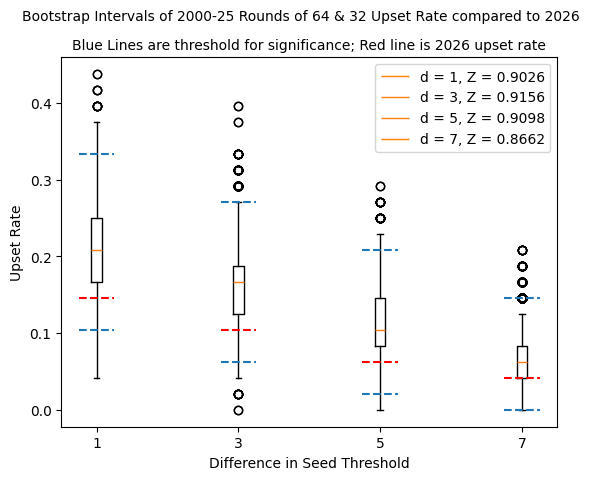

In [ ]:
for diff in {1, 3, 5, 7}:
    temp = results.loc[(results["round"].isin({64, 32})) & (((results['seed_team1'] > diff + results["seed_team2"]) & (results["win_team1"] == 1)) |
                ((results['seed_team1'] + diff < results["seed_team2"]) & (results["win_team1"] == 0))),].copy()
    temp = temp.groupby("year").count()["region"].reset_index().rename(columns = {"region" : "count"})
    occ: int = temp.iloc[:-1,1].values.sum()
    occ26: int = temp.iloc[-1,1] #/63
    n: int = 25*48
    inv = np.array([1]*occ + [0]*(n - occ))
    # inv26 = np.array([1]*occ26 + [0]*(63 - occ26))
    B: int = 5000
    res = np.zeros(shape = B)
    for i in range(B):
        # boot = np.random.choice(inv, size = len(inv26), replace = True)
        # boot26 = np.random.choice(inv26, size = len(inv26), replace=True)
        # res[i] = np.mean(boot) - np.mean(boot26)
        # boot = np.random.choice(inv, size = len(inv), replace = True)
        boot = np.random.choice(inv, size = 48, replace = True)
        # boot26 = np.random.choice(inv26, size = len(inv26), replace=True)
        res[i] = np.mean(boot)
        # res[i] = np.mean(boot) - occ26/63 # np.mean(boot26)
    # plt.boxplot(x = res, positions = [diff], label = f"Diff = {diff}, Median Upset% diff = {np.round(np.quantile(res, .5),2)}")
    # plt.boxplot(x = res, positions = [diff], label = f"d = {diff}, Z = {np.mean(res >= 0)}")
    plt.boxplot(x = res, positions = [diff], label = f"d = {diff}, Z = {np.mean(res >= occ26/48)}")
    plt.hlines(y = occ26/48, linestyles="dashed", xmin = diff - .25, xmax = diff + .25, color = "red")
    plt.hlines(y = np.quantile(res, .975), linestyles="dashed", xmin = diff - .25, xmax = diff + .25)
    plt.hlines(y = np.quantile(res, .025), linestyles="dashed", xmin = diff - .25, xmax = diff + .25)
# plt.hlines(y = 0, linestyles="dashed", xmin = 0.5, xmax = 6.5, color = "red")
plt.legend()
plt.suptitle("Bootstrap Intervals of 2000-25 Rounds of 64 & 32 Upset Rate compared to 2026", fontsize = 10)
plt.title("Blue Lines are threshold for significance; Red line is 2026 upset rate", fontsize = 10)
plt.ylabel("Upset Rate")
plt.xlabel("Difference in Seed Threshold")
plt.show()

In [ ]:
res = results.loc[results["year"] == 2026,]

,year,region,round,team1,team2,seed_team1,seed_team2,win_team1,seed_diff,is_upset
1574,2026,east,64,Duke,Siena,1,16,1,-15,0
1575,2026,east,64,Ohio State,TCU,8,9,0,-1,0
1576,2026,east,64,St. John's (NY),Northern Iowa,5,12,1,-7,0
1577,2026,east,64,Kansas,California Baptist,4,13,1,-9,0
1578,2026,east,64,Louisville,South Florida,6,11,1,-5,0
...,...,...,...,...,...,...,...,...,...,...
1632,2026,west,16,Texas,Purdue,11,2,0,9,0
1633,2026,west,8,Arizona,Purdue,1,2,1,-1,0
1634,2026,national,4,UConn,Illinois,2,3,1,-1,0
1635,2026,national,4,Michigan,Arizona,1,1,1,0,0


In [ ]:
mine = pd.read_csv("prediction_resultsCSV.csv")
# (mine.loc[(mine["on_path"] == 1) & (mine["Upset"] == 1),])
mine = mine.groupby("Round")["Points"].max().reset_index()
pts = {mine["Round"][i]: mine["Points"][i] for i in range(6)}
mine = pd.read_csv("prediction_resultsCSV.csv")
mine["max_pts"] = [pts[round] for round in mine["Round"]]

In [ ]:
temp = mine.sort_values("bce_loss", ascending=False).head(10).copy()
temp["team1_wseed"] = list(f"({temp["team1_seed"].iloc[i]}) {temp["team1"].iloc[i]}" for i in range(10))
temp["team2_wseed"] = list(f"({temp["team2_seed"].iloc[i]}) {temp["team2"].iloc[i]}" for i in range(10))
temp[["team1_wseed","team2_wseed", "team1_win_pred", "bce_loss"]]

,team1_wseed,team2_wseed,team1_win_pred,bce_loss
3,(5) Wisconsin,(12) High Point,0.8577,1.9498
59,(1) Duke,(2) UConn,0.7609,1.4309
8,(6) UNC,(11) VCU,0.7275,1.3002
44,(1) Florida,(9) Iowa,0.7239,1.2870
35,(3) Gonzaga,(11) Texas,0.6841,1.1523
10,(6) BYU,(11) Texas,0.6512,1.0533
49,(4) Nebraska,(9) Iowa,0.6287,0.9907
55,(2) Iowa State,(6) Tennessee,0.6266,0.9851
61,(2) UConn,(3) Illinois,0.4211,0.8649
0,(8) Ohio State,(9) TCU,0.5775,0.8615


In [ ]:
(mine.loc[(mine["on_path"] == 1) & (mine["Upset"] == 1),])#.sum()[["Points", "max_pts"]]

,Date,Round,team1_seed,team1,team2_seed,team2,team1_win_pred,team1_win,bce_loss,on_path,Upset,Pick,Correct,Points,max_pts
0,3/19/26,Round of 64,8,Ohio State,9,TCU,0.5775,0,0.8615,1,1,TCU,1,10,10
3,3/19/26,Round of 64,5,Wisconsin,12,High Point,0.8577,0,1.9498,1,1,Wisconsin,0,0,10
8,3/19/26,Round of 64,6,UNC,11,VCU,0.7275,0,1.3002,1,1,VCU,1,10,10
10,3/19/26,Round of 64,6,BYU,11,Texas,0.6512,0,1.0533,1,1,Texas,1,10,10
11,3/19/26,Round of 64,7,Saint Mary's,10,Texas A&M,0.4969,0,0.6869,1,1,Texas A&M,1,10,10
13,3/19/26,Round of 64,8,Georgia,9,Saint Louis,0.5732,0,0.8514,1,1,Saint Louis,1,10,10
22,3/20/26,Round of 64,8,Villanova,9,Utah State,0.5212,0,0.7365,1,1,Utah State,1,10,10
24,3/20/26,Round of 64,8,Clemson,9,Iowa,0.4967,0,0.6866,1,1,Iowa,1,10,10
35,3/21/26,Round of 32,3,Gonzaga,11,Texas,0.6841,0,1.1523,1,1,Gonzaga,0,0,20
42,3/22/26,Round of 32,4,Kansas,5,St. John's (NY),0.4265,0,0.5560,1,1,St. John's (NY),1,20,20


In [ ]:
df = pd.DataFrame({
    "after" : [str(i) for i in ["Entering",64,32,16,8,4,2]],
    "name" : ["Entering", "Round of 64", "Round of 32", "Sweet 16", "Elite 8", "Final Four", "Champ"],
    "max_pts" : [1920,1890,1790,1430,1350,1350,1350]
})
plt.bar(df["after"], df["max_pts"])
plt.text(x = df["after"], y = df["max_pts"], s = df["name"])
plt.ylim(0,2000)
plt.yticks(np.arange(2240, step = 320))
plt.xlabel("Round")
# plt.xticks(rotation = 40, ha = "right")
plt.show()

TypeError: only length-1 arrays can be converted to Python scalars

<Figure size 640x480 with 1 Axes>

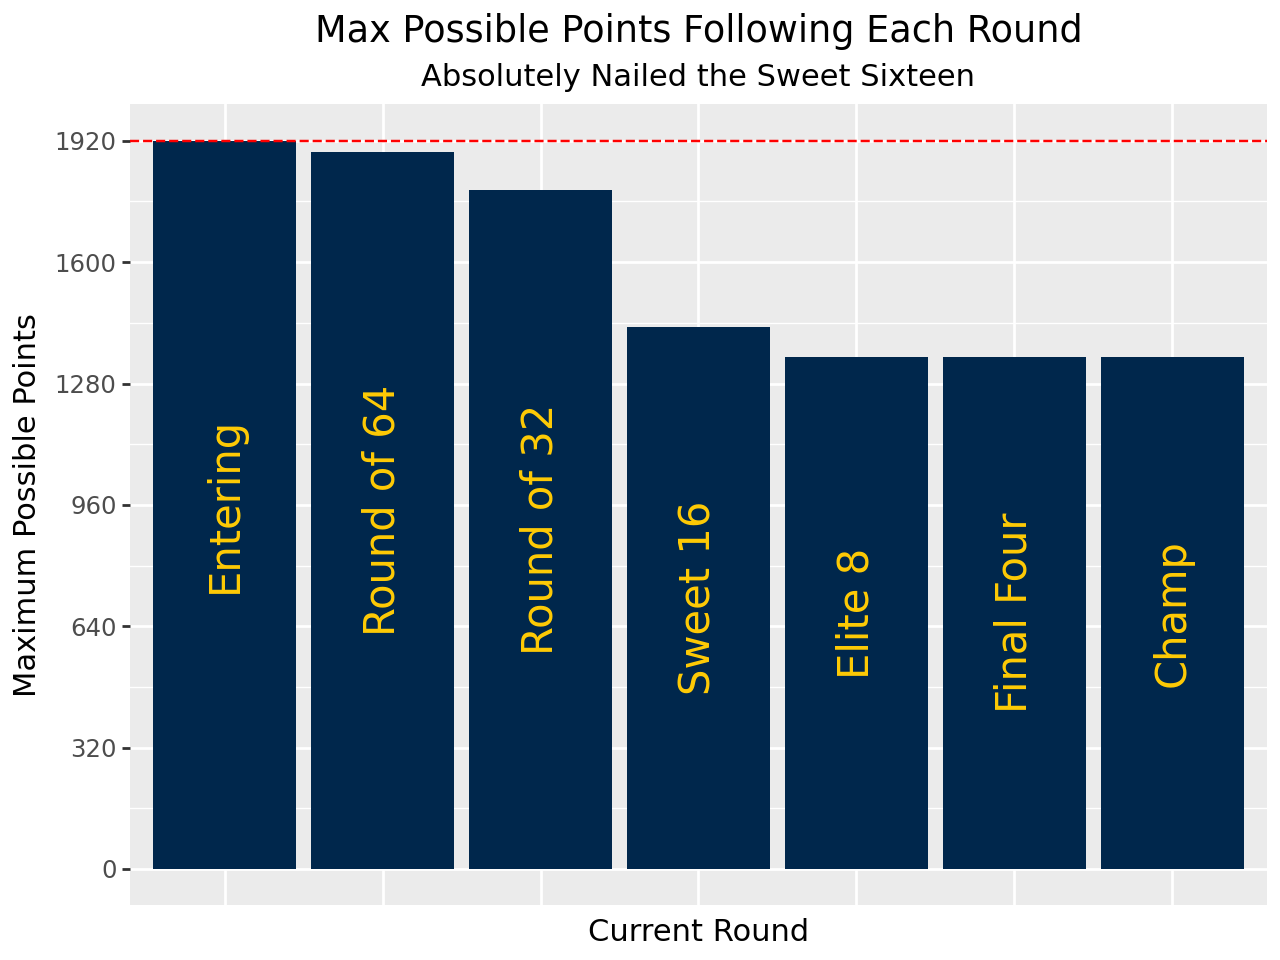

In [ ]:
# from plotnine import *

df = pd.DataFrame({
    "after" : [str(i) for i in ["Entering",64,32,16,8,4,2]],
    "name" : ["Entering", "Round of 64", "Round of 32", "Sweet 16", "Elite 8", "Final Four", "Champ"],
    "max_pts" : [1920,1890,1790,1430,1350,1350,1350]
})

df['after'] = pd.Categorical(df['after'], categories=df["after"], ordered=True)
ggplot(df) + geom_col(aes(x = "factor(after)", y = "max_pts"), fill = "#00274C") + geom_text(
    aes(x = "factor(after)", y = "max_pts/2", label = "name"), angle = 90,
    size = 15, color = "#FFCB05") + geom_hline(yintercept = 1920, color = "red", linetype = "dashed"
    ) + theme(axis_ticks_x = element_blank(), axis_text_x = element_blank(),
    plot_title = element_text(hjust = 0.5), plot_subtitle = element_text(hjust = .5)) + xlab(
  "Current Round") + ylab("Maximum Possible Points") + scale_y_continuous(
  breaks = range(0,2240,320)) + labs(
  title = "Max Possible Points Following Each Round",
  subtitle = "Absolutely Nailed the Sweet Sixteen")

In [ ]:
list(str(int(picks[1][i])) + "/" + str(int(picks["total"][i])) for i in range(6))

['1/1', '2/4', '4/8', '13/16', '29/32', '1/2']

In [ ]:
picks = mine.groupby(["round","Correct"], observed = False).count()["Round"].reset_index().pivot(index = "round", columns = "Correct", values = "Round").reset_index() #.fillna(0)
picks["total"] = picks[0] + picks[1]
picks["format"] = list(str(int(picks[1][i])) + "/" + str(int(picks["total"][i])) for i in range(6))
picks

Correct,round,0,1,total,format
0,Round of 64,3,29,32,29/32
1,Round of 32,3,13,16,13/16
2,Round of 16,4,4,8,4/8
3,Quarterfinal,2,2,4,2/4
4,Semifinal,1,1,2,1/2
5,Final,0,1,1,1/1


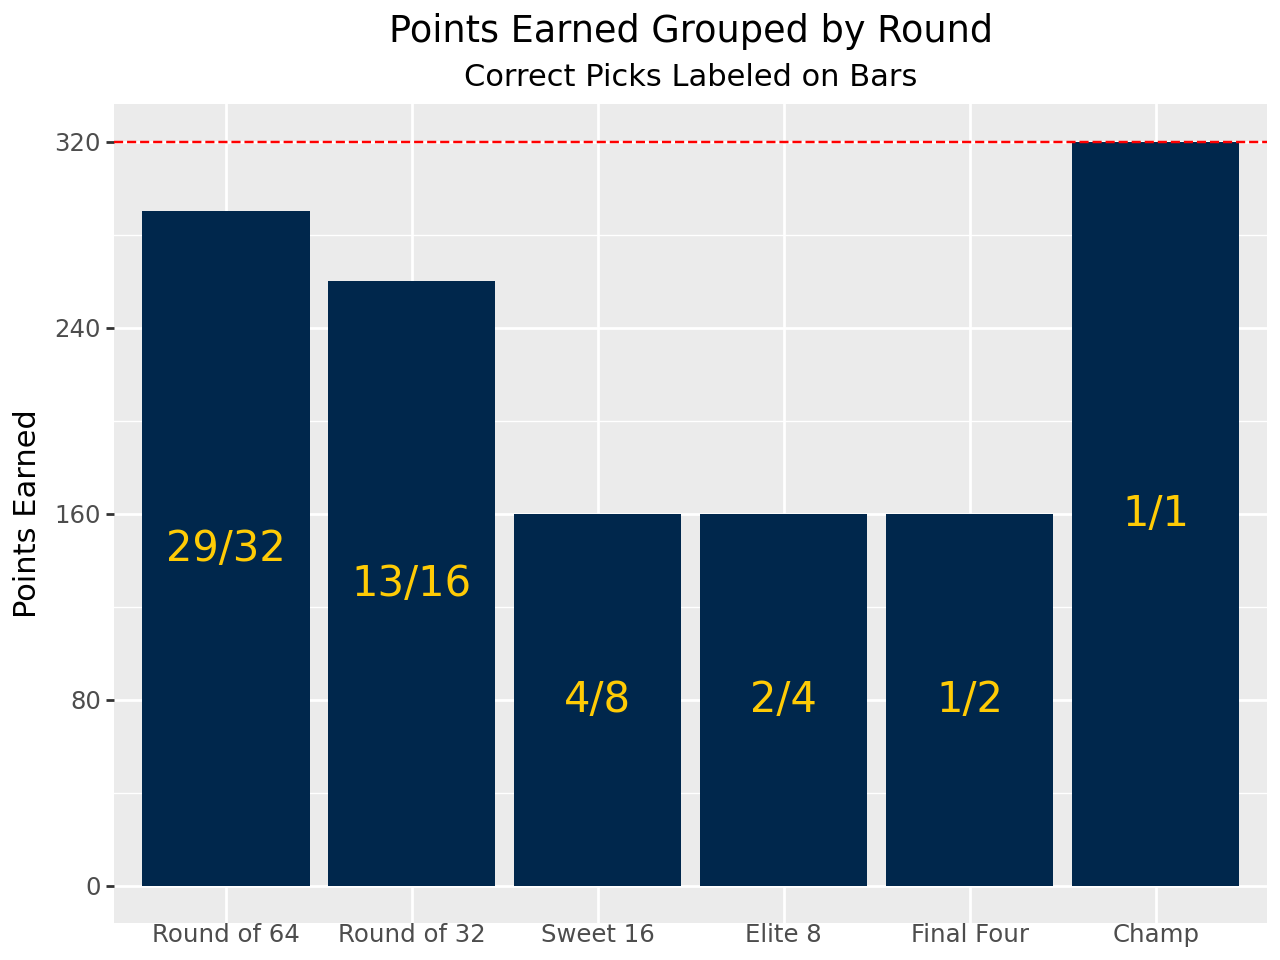

In [ ]:
mine = pd.read_csv("prediction_resultsCSV.csv")
mine["round"] = pd.Categorical(mine["Round"], categories = list(mine["Round"].unique()), ordered = True)
temp = mine.groupby("round", observed=False)["Points"].sum().reset_index().copy()
# temp["round"] = pd.Categorical(mine["Round"].unique(), categories = list(mine["Round"].unique()), ordered = True)
temp["name"] = df["name"].values[1:]
temp["picks"] = picks["format"]

ggplot(temp) + geom_col(aes(x = "factor(round)", y = "Points"), fill = "#00274C") + xlab(
"") + scale_x_discrete(labels = {temp["round"][i] : temp["name"][i] for i in range(6)}
 ) + scale_y_continuous(breaks = range(0,400, 80)) + geom_text(aes(x = "factor(round)",
 y = "Points/2", label = "picks"), size = 15, color = "#FFCB05") + ylab("Points Earned"
 ) + labs(title = "Points Earned Grouped by Round",
 subtitle = "Correct Picks Labeled on Bars") + theme(axis_ticks_x = element_blank(),
    plot_title = element_text(hjust = 0.5), plot_subtitle = element_text(hjust = .5)
  ) + geom_hline(yintercept = 320, color = "red", linetype = "dashed")

In [ ]:
mine.loc[mine["on_path"] == 1,].sort_values("bce_loss", ascending = False).head(5)

,Date,Round,team1_seed,team1,team2_seed,team2,team1_win_pred,team1_win,bce_loss,on_path,Upset,Pick,Correct,Points,round
3,3/19/26,Round of 64,5,Wisconsin,12,High Point,0.8577,0,1.9498,1,1,Wisconsin,0,0,Round of 64
8,3/19/26,Round of 64,6,UNC,11,VCU,0.7275,0,1.3002,1,1,VCU,1,10,Round of 64
44,3/22/26,Round of 32,1,Florida,9,Iowa,0.7239,0,1.2870,1,1,Florida,0,0,Round of 32
35,3/21/26,Round of 32,3,Gonzaga,11,Texas,0.6841,0,1.1523,1,1,Gonzaga,0,0,Round of 32
10,3/19/26,Round of 64,6,BYU,11,Texas,0.6512,0,1.0533,1,1,Texas,1,10,Round of 64


In [ ]:
results = pd.read_csv("MMresults.csv")
results = results.loc[results["year"] == 2026,]
results["winner"] = results["team1"]
results.loc[results["win_team1"] == 0, "winner"] = results["team2"]
results

,year,region,round,team1,team2,seed_team1,seed_team2,win_team1,winner
1574,2026,east,64,Duke,Siena,1,16,1,Duke
1575,2026,east,64,Ohio State,TCU,8,9,0,TCU
1576,2026,east,64,St. John's (NY),Northern Iowa,5,12,1,St. John's (NY)
1577,2026,east,64,Kansas,California Baptist,4,13,1,Kansas
1578,2026,east,64,Louisville,South Florida,6,11,1,Louisville
...,...,...,...,...,...,...,...,...,...
1632,2026,west,16,Texas,Purdue,11,2,0,Purdue
1633,2026,west,8,Arizona,Purdue,1,2,1,Arizona
1634,2026,national,4,UConn,Illinois,2,3,1,UConn
1635,2026,national,4,Michigan,Arizona,1,1,1,Michigan


In [ ]:
mine = pd.read_csv("prediction_resultsCSV.csv")
mine["winner"] = mine["team1"]
mine.loc[mine["team1_win"] == 0, "winner"] = mine["team2"]
(mine[["Round","team1", "team2", "winner", "Pick"]])

,Round,team1,team2,winner,Pick
0,Round of 64,Ohio State,TCU,TCU,TCU
1,Round of 64,Nebraska,Troy,Nebraska,Nebraska
2,Round of 64,Louisville,South Florida,Louisville,South Florida
3,Round of 64,Wisconsin,High Point,High Point,Wisconsin
4,Round of 64,Duke,Siena,Duke,Duke
...,...,...,...,...,...
58,Quarterfinal,Michigan,Tennessee,Michigan,Michigan
59,Quarterfinal,Duke,UConn,UConn,Duke
60,Semifinal,Michigan,Arizona,Michigan,Michigan
61,Semifinal,UConn,Illinois,UConn,Houston


In [ ]:
mine.loc[(abs(mine["team1_seed"] - mine["team2_seed"]) == 5) & (mine["on_path"] == 1), ]

,Date,Round,team1_seed,team1,team2_seed,team2,team1_win_pred,team1_win,bce_loss,on_path,Upset,Pick,Correct,Points,winner
2,3/19/26,Round of 64,6,Louisville,11,South Florida,0.6410,1,0.4447,1,0,South Florida,0,0,Louisville
8,3/19/26,Round of 64,6,UNC,11,VCU,0.7275,0,1.3002,1,1,VCU,1,10,VCU
10,3/19/26,Round of 64,6,BYU,11,Texas,0.6512,0,1.0533,1,1,Texas,1,10,Texas
23,3/20/26,Round of 64,6,Tennessee,11,Miami (OH),0.7521,1,0.2849,1,0,Tennessee,1,10,Tennessee
40,3/22/26,Round of 32,2,Purdue,7,Miami (FL),0.6644,1,0.4089,1,0,Purdue,1,20,Purdue
41,3/22/26,Round of 32,2,Iowa State,7,Kentucky,0.6979,1,0.3597,1,0,Iowa State,1,20,Iowa State


# scraping stats from 2000 to 2009

In [ ]:
header: str = "https://www.sports-reference.com"

In [ ]:
bracket_url: str = "https://www.sports-reference.com/cbb/postseason/men/2001-ncaa.html"
s = soupify(bracket_url)

In [ ]:
# scores = set(g["href"] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" not in g["href"])
# scores

In [ ]:
list(scores)

['/cbb/boxscores/2000-03-16-iona.html',
 '/cbb/boxscores/2000-03-16-ball-state.html',
 '/cbb/boxscores/2000-03-16-arizona.html',
 '/cbb/boxscores/2000-03-18-arizona.html',
 '/cbb/boxscores/2000-03-18-oklahoma.html',
 '/cbb/boxscores/2000-03-17-duke.html',
 '/cbb/boxscores/2000-03-26-florida.html',
 '/cbb/boxscores/2000-03-17-hofstra.html',
 '/cbb/boxscores/2000-03-17-butler.html',
 '/cbb/boxscores/2000-03-17-south-carolina-state.html',
 '/cbb/boxscores/2000-03-17-louisiana-lafayette.html',
 '/cbb/boxscores/2000-03-16-louisiana-state.html',
 '/cbb/boxscores/2000-03-17-connecticut.html',
 '/cbb/boxscores/2000-03-19-north-carolina.html',
 '/cbb/boxscores/2000-03-16-indiana-state.html',
 '/cbb/boxscores/2000-03-16-saint-louis.html',
 '/cbb/boxscores/2000-03-19-connecticut.html',
 '/cbb/boxscores/2000-03-24-north-carolina.html',
 '/cbb/boxscores/2000-03-17-lafayette.html',
 '/cbb/boxscores/2000-03-24-duke.html',
 '/cbb/boxscores/2000-03-16-central-connecticut-state.html',
 '/cbb/boxscores/2

In [ ]:
s1 = soupify(header + list(scores)[3])

In [ ]:
# getting teams
# teams = list(i["id"].split('basic-')[1] for i in s1.find_all('table', {"class" : "sortable stats_table"}))

In [ ]:
# set(g["href"].split('schools/')[1].split('/men')[0] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" in g["href"])

In [ ]:
stats = ["games", 'mp', 'fg', 'fga',
 'fg2','fg2a', 'fg3',
 'fg3a','ft','fta', 'orb',
 'drb', 'trb', 'ast',
 'stl', 'blk', 'tov','pf','pts']

In [ ]:
# getting stats columns
# list(th.get('data-stat') for th in s1.find_all('table', {"class" : "sortable stats_table"})[0].find('tr', {"class":"thead"}).find_all('th'))
# list(s1.find_all('table', {"class" : "sortable stats_table"})[0].find('tfoot').find('td', {"data-stat" : col}) for col in stats )
stats_dict = {t: {col : 0 for col in stats} for t in teams}
opp_dict = {t: {"opp_" + col : 0 for col in stats} for t in teams}
for team in teams:
    if team not in stats_dict.keys():
        stats_dict[t] = {col : 0 for col in stats}
        opp_dict[t] = {"opp_" + col : 0 for col in stats}
for table in s1.find_all('table', {"class" : "sortable stats_table"}):
    team = table["id"].split('basic-')[1]
    if team in stats_dict.keys():
        stats_dict[team] = {col : stats_dict[team][col] + float(table.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "gp" else stats_dict[team][col] + 1 for col in stats}
    else:
        stats_dict[team] = {col : float(table.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "gp" else 1 for col in stats}
t1, t2 = list(i["id"].split('basic-')[1] for i in s1.find_all('table', {"class" : "sortable stats_table"}))
if t1 in opp_dict.keys():
    opp_dict[t1] = {"opp_" + col : opp_dict[t1]["opp_" + col] + stats_dict[t2][col] for col in stats}
else:
    opp_dict[t1] = {"opp_" + col : stats_dict[t2][col] for col in stats}
if t2 in opp_dict.keys():
    opp_dict[t2] = {"opp_" + col : opp_dict[t2]["opp_" + col] + stats_dict[t1][col] for col in stats}
else:
    opp_dict[t2] = {"opp_" + col : stats_dict[t1][col] for col in stats}

In [ ]:
teams = set(g["href"].split('schools/')[1].split('/men')[0] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" in g["href"])
stats_dict = {t: {col : 0 for col in stats} for t in teams}
opp_dict = {t: {"opp_" + col : 0 for col in stats} for t in teams}
for score in scores:
    s1 = soupify(header + score)
    # for table in s1.find_all('table', {"class" : "sortable stats_table"}):
    tab1, tab2 = s1.find_all('table', {"class" : "sortable stats_table"})
    # t1, t2 = list(i["id"].split('basic-')[1] for i in s1.find_all('table', {"class" : "sortable stats_table"}))
    t1 = tab1["id"].split('basic-')[1]
    t2 = tab2["id"].split('basic-')[1]
    stats_dict[t1] = {col : stats_dict[t1][col] + float(tab1.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else stats_dict[t1][col] + 1 for col in stats}
    stats_dict[t2] = {col : stats_dict[t2][col] + float(tab2.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else stats_dict[t2][col] + 1 for col in stats}

    opp_dict[t1] = {"opp_" + col : opp_dict[t1]["opp_" + col] + float(tab2.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else opp_dict[t1]["opp_" + col] + 1 for col in stats}
    opp_dict[t2] = {"opp_" + col : opp_dict[t2]["opp_" + col] + float(tab1.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else opp_dict[t2]["opp_" + col] + 1 for col in stats}
        # team = table["id"].split('basic-')[1]
        # if team in stats_dict.keys():
        # stats_dict[team] = {col : stats_dict[team][col] + float(table.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "gp" else stats_dict[team][col] + 1 for col in stats}
        # else:
        #     stats_dict[team] = {col : float(table.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "gp" else 1 for col in stats}
    # t1, t2 = list(i["id"].split('basic-')[1] for i in s1.find_all('table', {"class" : "sortable stats_table"}))
    # if t1 in opp_dict.keys():
    # opp_dict[t1] = {"opp_" + col : opp_dict[t1]["opp_" + col] + stats_dict[t2][col] for col in stats}
    # else:
    #     opp_dict[t1] = {"opp_" + col : stats_dict[t2][col] for col in stats}
    # if t2 in opp_dict.keys():
    # opp_dict[t2] = {"opp_" + col : opp_dict[t2]["opp_" + col] + stats_dict[t1][col] for col in stats}
    # else:
    #     opp_dict[t2] = {"opp_" + col : stats_dict[t1][col] for col in stats}
    sleep(5)

In [ ]:
df = pd.DataFrame(columns = ["year","team"] + stats)
opp_df = pd.DataFrame(columns = ["year", "team"] + list("opp_" + s for s in stats))
for team in teams:
    df.loc[len(df.index)] = [2000, team] + list(stats_dict[team].values())
    opp_df.loc[len(opp_df.index)] = [2000, team] + list(opp_dict[team].values())

In [ ]:
df.to_csv("tourney_stats2000.csv", index = False)
opp_df.to_csv("tourney_opp_stats2000.csv", index = False)

In [ ]:
urls = set(g["href"] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" in g["href"])
s1 = soupify(header + list(urls)[0])

In [ ]:
for team in teams:
    stats_dict[team]["games"] = stats_dict[team]["gp"]
    opp_dict[team]["opp_games"] = opp_dict[team]["opp_gp"]

In [ ]:
header + list(urls)[0]

'https://www.sports-reference.com/cbb/schools/illinois/men/2000.html'

In [ ]:
{p.find('a').contents[0]:float(p.contents[1].split(' ')[1]) for p in s1.find_all('p') if p.find('a') and any(i in p.find('a')["href"] for i in {"sos","srs"})}

{'SRS': 19.73, 'SOS': 9.6}

In [ ]:
team_stats = {col: s1.find('table', {"id" : "season-total_totals"}).find('td', {"data-stat" : col}).contents[0] for col in stats}
# list(t["id"] for t in s1.find_all('table') if t.get('id'))
opp_stats = {"opp_" + col: s1.find('table', {"id" : "season-total_totals"}).find('td', {"data-stat" : "opp_" + col}).contents[0] if col not in ["games","mp"] else s1.find('table', {"id" : "season-total_totals"}).find('td', {"data-stat" :col}).contents[0] for col in stats}

In [ ]:
urls = set(g["href"] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" in g["href"])
team_stats = {team : {col:0 for col in stats} for team in teams}
opp_stats = {team : {"opp_" + col:0 for col in stats} for team in teams}
adv_stats = {team : {col:0 for col in ["SRS", "SOS"]}}
for url in urls:
    team = url.split('schools/')[1].split('/men')[0]
    s1 = soupify(header + url)
    table = s1.find('table', {"id" : "season-total_totals"})
    team_stats[team] = {col: int(table.find('td', {"data-stat" : col}).contents[0]) if table.find('td', {"data-stat" : col}).contents else np.nan for col in stats}
    opp_stats[team] = {"opp_" + col: int(table.find('td', {"data-stat" : "opp_" + col}).contents[0]) if col not in ["games","mp"] else int(table.find('td', {"data-stat" :col}).contents[0]) for col in stats}
    adv_stats[team] = {p.find('a').contents[0]:float(p.contents[1].split(' ')[1]) for p in s1.find_all('p') if p.find('a') and any(i in p.find('a')["href"] for i in {"sos","srs"})}
    sleep(5)

In [ ]:
reg_stats = {team : {col:0 for col in stats} for team in teams}
reg_opp = {team : {"opp_" + col:0 for col in stats} for team in teams}
for team in teams:
    reg_stats[team] = {col: team_stats[team][col] - stats_dict[team][col] for col in reg_stats[team].keys()}
    reg_opp[team] = {col: opp_stats[team][col] - opp_dict[team][col] for col in reg_opp[team].keys()}

In [ ]:
df = pd.DataFrame(columns = ["year", "team", "SRS", "SOS"] + list(reg_stats[team].keys()) + list(reg_opp[team].keys()))
for team in teams:
    df.loc[len(df.index)] = [2000, team] + list(adv_stats[team].values()) + list(reg_stats[team].values()) + list(reg_opp[team].values())

In [ ]:
stats = ["games", 'mp', 'fg', 'fga',
 'fg2','fg2a', 'fg3',
 'fg3a','ft','fta', 'orb',
 'drb', 'trb', 'ast',
 'stl', 'blk', 'tov','pf','pts']
opp_cols = list("opp_" + s if s not in {"games", "mp"} else s for s in stats)

for year in range(2005, 2010):
    start = time()
    bracket_url: str = f"https://www.sports-reference.com/cbb/postseason/men/{year}-ncaa.html"
    s = soupify(bracket_url)

    sleep(5)

    scores = set(g["href"] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" not in g["href"])

    # teams = list(i["id"].split('basic-')[1] for i in s1.find_all('table', {"class" : "sortable stats_table"}))

    teams = set(g["href"].split('schools/')[1].split('/men')[0] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" in g["href"])
    stats_dict = {t: {col : 0 for col in stats} for t in teams}
    # opp_dict = {t: {"opp_" + col : 0 for col in opp_cols} for t in teams}
    opp_dict = {t: {col : 0 for col in opp_cols} for t in teams}
    for score in scores:
        s1 = soupify(header + score)
        # for table in s1.find_all('table', {"class" : "sortable stats_table"}):
        # tab1, tab2 = s1.find_all('table', {"class" : "sortable stats_table"})
        tab1, tab2 = list(t for t in s1.find_all('table', {"class" : "sortable stats_table"}) if "basic" in t["id"])
        # t1, t2 = list(i["id"].split('basic-')[1] for i in s1.find_all('table', {"class" : "sortable stats_table"}))
        t1 = tab1["id"].split('basic-')[1]
        t2 = tab2["id"].split('basic-')[1]
        stats_dict[t1] = {col : stats_dict[t1][col] + float(tab1.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else stats_dict[t1][col] + 1 for col in stats}
        stats_dict[t2] = {col : stats_dict[t2][col] + float(tab2.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else stats_dict[t2][col] + 1 for col in stats}

        # opp_dict[t1] = {"opp_" + col : opp_dict[t1]["opp_" + col] + float(tab2.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else opp_dict[t1]["opp_" + col] + 1 for col in stats}
        # opp_dict[t2] = {"opp_" + col : opp_dict[t2]["opp_" + col] + float(tab1.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else opp_dict[t2]["opp_" + col] + 1 for col in stats}

        # opp_dict[t1] = {col : opp_dict[t1][col] + float(tab2.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else opp_dict[t1][col] + 1 for col in opp_cols}
        # opp_dict[t2] = { col : opp_dict[t2][col] + float(tab1.find('tfoot').find('td', {"data-stat" : col}).contents[0]) if col != "games" else opp_dict[t2][col] + 1 for col in opp_cols}

        opp_dict[t1] = {col : opp_dict[t1][col] + float(tab2.find('tfoot').find('td', {"data-stat" : col.split("_")[-1]}).contents[0]) if col != "games" else opp_dict[t1][col] + 1 for col in opp_cols}
        opp_dict[t2] = { col : opp_dict[t2][col] + float(tab1.find('tfoot').find('td', {"data-stat" : col.split("_")[-1]}).contents[0]) if col != "games" else opp_dict[t2][col] + 1 for col in opp_cols}

        sleep(5)

    urls = set(g["href"] for g in s.find('div', {"id" : "brackets"}).find_all('a') if "schools" in g["href"])
    team_stats = {team : {col:0 for col in stats} for team in teams}
    # opp_stats = {team : {"opp_" + col:0 for col in stats} for team in teams}
    opp_stats = {team : {col:0 for col in opp_cols} for team in teams}
    adv_stats = {team : {col:0 for col in ["SRS", "SOS"]} for team in teams}
    for url in urls:
        team = url.split('schools/')[1].split('/men')[0]
        s1 = soupify(header + url)
        table = s1.find('table', {"id" : "season-total_totals"})
        team_stats[team] = {col: int(table.find('td', {"data-stat" : col}).contents[0]) if table.find('td', {"data-stat" : col}).contents else np.nan for col in stats}
        # opp_stats[team] = {"opp_" + col: int(table.find('td', {"data-stat" : "opp_" + col}).contents[0]) if col not in ["games","mp"] else int(table.find('td', {"data-stat" :col}).contents[0]) for col in stats}
        opp_stats[team] = {col: int(table.find('td', {"data-stat" : col}).contents[0]) if table.find('td', {"data-stat" : col}).contents else np.nan for col in opp_cols}
        adv_stats[team] = {p.find('a').contents[0]:float(p.contents[1].split(' ')[1]) for p in s1.find_all('p') if p.find('a') and any(i in p.find('a')["href"] for i in {"sos","srs"})}
        sleep(5)

    reg_stats = {team : {col:0 for col in stats} for team in teams}
    reg_opp = {team : {col:0 for col in opp_cols} for team in teams}
    for team in teams:
        reg_stats[team] = {col: team_stats[team][col] - stats_dict[team][col] for col in reg_stats[team].keys()}
        # reg_opp[team] = {col: opp_stats[team][col] - opp_dict[team][col] for col in reg_opp[team].keys()}
        reg_opp[team] = {col: opp_stats[team][col] - opp_dict[team][col] for col in reg_opp[team].keys()}

    for team in teams:
        df.loc[len(df.index)] = [year, team] + list(adv_stats[team].values()) + list(reg_stats[team].values()) + list(reg_opp[team].values())
    print(f"{year}: {round((time() - start)/60, 3)} minutes")

2005: 11.842 minutes
2006: 11.816 minutes
2007: 11.88 minutes
2008: 11.829 minutes
2009: 11.816 minutes


In [ ]:
df.to_csv("teamstats2000s.csv", index = False)